# **Project Name : -**

##### **⭐PROJECT : - MACHINE LEARNING MODEL⭐**

##### ***Project Title :* - ✨ House Rent Prediction ✨**

##### ***Project Type :*    - ✨ EDA/Regression/Classification/Unsupervised ✨**

##### ***Project Submitted By :* - ✨ Nishant Shaileshkumar Trivedi ✨**

# **ML Model - House Rent Prediction**

In [ ]:
# Required Libraries

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Load Dataset
df = pd.read_csv('/content/House_Rent_Dataset.csv')

In [ ]:
# Settings To See Maximum Rows & Columns Of The Dataset
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [ ]:
# Display Dataset
print("Dataset:")
print(df)

Dataset:
       Posted On  BHK     Rent  Size                     Floor    Area Type  \
0     2022-05-18    2    10000  1100           Ground out of 2   Super Area   
1     2022-05-13    2    20000   800                1 out of 3   Super Area   
2     2022-05-16    2    17000  1000                1 out of 3   Super Area   
3     2022-07-04    2    10000   800                1 out of 2   Super Area   
4     2022-05-09    2     7500   850                1 out of 2  Carpet Area   
5     2022-04-29    2     7000   600           Ground out of 1   Super Area   
6     2022-06-21    2    10000   700           Ground out of 4   Super Area   
7     2022-06-21    1     5000   250                1 out of 2   Super Area   
8     2022-06-07    2    26000   800                1 out of 2  Carpet Area   
9     2022-06-20    2    10000  1000                1 out of 3  Carpet Area   
10    2022-05-23    3    25000  1200                1 out of 4  Carpet Area   
11    2022-06-07    1     5000   400       

In [ ]:
# Display first rows
print(df.head())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

In [ ]:
# Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None


In [ ]:
# Dataset shape
df.shape

(4746, 12)

In [ ]:
# Find The Missing values
print(df.isnull().sum())

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


In [ ]:
# Remove null values
df = df.dropna()

**Exploratory Data Analysis (EDA)**

In [ ]:
# Statistical Summary
print(df.describe())

               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75%       3.000000  3.300000e+04  1200.000000     2.000000
max       6.000000  3.500000e+06  8000.000000    10.000000


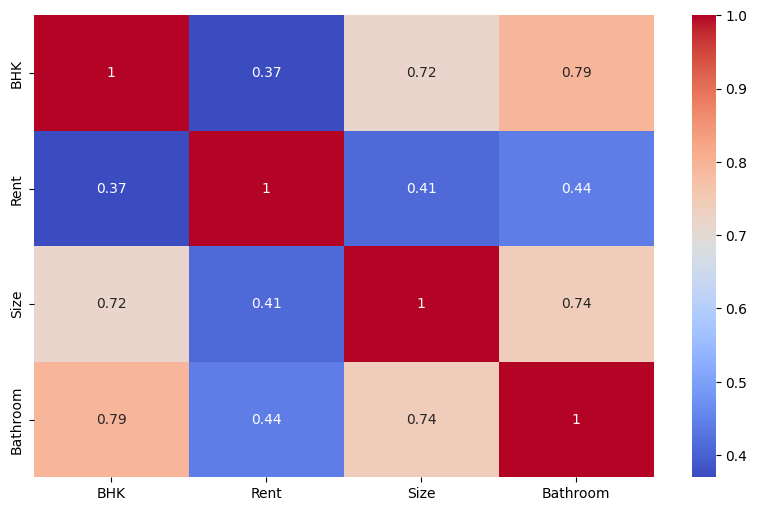

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Features and target
X = df[['Size', 'BHK', 'Bathroom']]
y = df['Rent']

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Create model
model = LinearRegression()

In [ ]:
# Train model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Check Model Coefficients
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coeff_df)

Intercept: -39022.92849685526
           Coefficient
Size         21.053941
BHK        -269.131569
Bathroom  27624.563039


In [ ]:
# Predict Values
y_pred = model.predict(X_test)

In [ ]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head())

      Actual      Predicted
1566   16000   38847.269247
3159   12000   32531.087027
538    28000   26593.875741
2630    8000   74624.277009
4418   46000  145348.049524


In [ ]:
# Evaluate the Model

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# R² Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 26191.95793986809
MSE: 2554775777.0452137
R2 Score: 0.35896327760744784


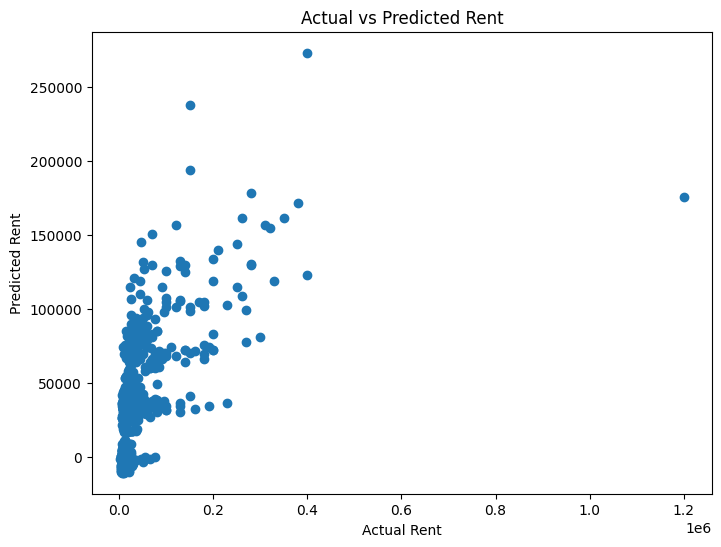

In [ ]:
# Visualization

# Actual vs Predicted Graph

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")

plt.show()

In [ ]:
# Predict Custom House Rent

custom_input = [[1200, 2, 2]]

prediction = model.predict(custom_input)

print("Predicted Rent:", prediction[0])

Predicted Rent: 40952.66332026


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
custom_input = [[1000, 2, 2]]

prediction = model.predict(custom_input)

print("Predicted Rent:", prediction[0])

Predicted Rent: 36741.875173864704


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# **360_F_949402314_z8RCdP8kIhYb2Sj6wzCZEnWwBJiI4B71.jpg**